In [170]:
using Pkg; Pkg.activate("..")
# Pkg.instantiate()

using Dates
using Statistics
using Interpolations
using ForwardDiff
using NCDatasets
using PyPlot

  Activating project at `~/Projects/ASTRAL/soundings`


In [2]:
using PyCall
using PyCall: PyObject

# PyObject method interprets Array{Union{T,Missing}} as a
# numpy masked array.
# This allows for plotting with missing values.
function PyObject(a::Array{Union{T,Missing},N}) where {T,N}
    numpy_ma = PyCall.pyimport("numpy").ma
    pycall(numpy_ma.array, Any, coalesce.(a,zero(T)), mask=ismissing.(a))
end

PyObject

In [3]:
module VaporSat

using ForwardDiff

export qs, dqsdT
export Twet_autodiff

# constants
Cp = 1005.7  # from my Davies-Jones function, was 1005.
Cpv = 1870.0 # J/kg/K
Cw  = 4190.0
L0 = 2.501e6 # J/kg

C = 273.15 # K
Rd = 287.04
Rv = 461.5
RdoRv=Rd/Rv

"latent heat of water vapor"
LvK(TempK) = L0 + (Cpv-Cw) * (TempK-273.0)

# functions
"""
es(T,p) = is saturation vapor pressure based on Wexler's formula,
with enhancement factor for moist air rather than water vapor.
The enhancement factor requires a pressure.
T [degrees C], p [Pa] (note the reversed input order), es [Pa]
Calling with optional keywords changes the units and
ignores the positional arguments.
es(T,p; TK=tk[Kelvin], P=pr[hPa])
From A. L. Buck 1981: JAM, 20, 1527-1532.
SPdeS 7 July 2004
"""
function es(T,p=1e5; P=p*1e-2)
    esat = 1e2 * 6.1121*(1.0007 + 3.46e-8*P)*exp((17.502*T)/(240.97 + T)) # convert es to Pa
end

# supply TK [Kelvin] by keyword, ignores positional T!!
function es(T,p=1e5; TK=T+C, P=p*1e-2)
    T = TK - C
    esat = 1e2 * 6.1121*(1.0007 + 3.46e-8*P)*exp((17.502*T)/(240.97 + T)) # convert es to Pa
end

"""
qs(p,T) is saturation specific humidity based on Wexler's formula for es
with enhancement factor (see es.m).
p [Pa], T [degrees C], qs [kg/kg]
From A. L. Buck 1981: JAM, 20, 1527-1532.
SPdeS 7 July 2004
"""
qs(p,T) = RdoRv*es(T,p) / (p + (RdoRv-1)*es(T,p))

"dqsdT(p,T[C]) derivative of qs with respect to T at p,T by autodiff of Bolton's qs"
dqsdT(p,T) = ForwardDiff.derivative(t -> qs(p,t), T)
# assumes isobaric

# wet bulb temperature methods
# for approximating the evap process

"General single Newton iteration to update x toward f(x) = fhat for a univariate function f"
updatex(f, x, fhat=0) = x + (fhat-f(x)) / ForwardDiff.derivative(f, x)

"""
Twet_autodiff(T[K], q[kg/kg], p[Pa]; niter=2) wet bulb temperature using Newton's method
for target specific humidity q[kg/kg]. Uses automatic differntiation.
"""
function Twet_autodiff(T, q, p; niter=2)
    f(t) = (t - T) + LvK((T+t)/2)/Cp * (qs(p,t-C) - q)
    t=T
    for i in 1:niter
        t = updatex(f, t, 0)
    end
    t
end
# 2 iterations converges to ~0.001 K

# call as...
# q = rh*qs(pa, Ta)
# Twet_autodiff(Ta, rh*qs(pa, Ta-C), pa) 

end # module VaporSat

using .VaporSat

In [4]:
# thermo functions

"Exner function = T/θ = (p/p0)^(Rd/Cp)"
Exner(p; p0=1000.0) = (p/p0)^0.287
Exner(p, qv; p0=1000.0) = (p/p0) ^ ((Rd/Cp) * (1 - 0.28*qv))

"potential temperature [K] = theta(T[K], p[hPa])"
theta(T, p) = T/Exner(p)
theta(T, p, qv) = T/Exner(p, qv)

theta (generic function with 2 methods)

In [ ]:
# data processing functions

"convert filename to datetime"
function extract_datetime(filename::String)
    m = match(r"(\d{8})_(\d{4})", filename)
    if m !== nothing
        date_str = m.captures[1]  # "20250704"
        time_str = m.captures[2]  # "0000"
        return DateTime(date_str * time_str, "yyyymmddHHMM")
    else
        error("No valid datetime found in filename.")
    end
end

# Interpolation methods
# Pressure is irregular and different for each sounding time.

function isvalid(x)
    !ismissing(x) && isfinite(x)
end
function valid_mask(arrays::Tuple)
    map( t -> all(isvalid, t), zip(arrays...))
end
function valid_inds(arrays::Tuple)
    findall(t -> all(isvalid, t), zip(arrays...))
end

# interpolation functions
function itp_sparse(x::Vector, p::Vector)
    # knot-vectors must be unique and sorted in increasing order
    ind = sortperm(p)
    ii = valid_mask( (p[ind],) )
    inter = interpolate( (p[ind][ii],), x[ind][ii], Gridded(Linear()) )
    extrapolate( inter, NaN )
end

"interpolation function that filters missing data from the input sounding before interpolating."
function itp(x::Vector, p::Vector)
    # knot-vectors must be unique and sorted in increasing order
    ind = sortperm(p)
    pt = p[ind]
    xt = x[ind]
    ii = valid_mask((pt, xt)) # .& .!ismissing.(p[ind] .+ x[ind])
    if sum(ii) > 1
        inter = interpolate( (pt[ii],), xt[ii], Gridded(Linear()) )
        return extrapolate( inter, NaN )
    else
        return x -> NaN # fallback interpolation function returns only NaN
    end
end

# pressure levels to interploate to
dp = 50.0
plevs = 1000.0:-dp:0.0

"rectangular interval averaging onto a decreasing pressure coordinate"
function pavg(x::Vector, p::Vector; plevs=plevs)
    s1 = zeros(Float64, size(plevs))
    # s2 = zeros(Float64, size(p))
    ns = zeros(Float64, size(plevs))
    
    for i in eachindex(p)
        j = findfirst(x -> x < p[i], plevs) # j indexes plevs
        if !isnothing(j)
            s1[j] += isfinite(x[i]) ? x[i] : 0
            # s2[j] += x[i]^2
            ns[j] += 1.0*isfinite(x[i])
        end
    end
    
    s1 ./ ns # mean
end



pavg

In [169]:
"climatological average on monthday dt"
function climprof(x, dt, cdt=sort(unique(dt)), bincond = (x,y) -> map(==(x),y))
    ax = zeros(Float64, size(x,1), size(cdt,1))
    sx = zeros(Int64,   size(x,1), size(cdt,1))
    for I in CartesianIndices(x)
        i = I[1]; j = I[2]
        jc = bincond(dt[j], cdt) # bool mask with at most 1 true
        if any(jc) && !ismissing(x[i,j]) && isfinite(x[i,j])
            ax[i,jc] .+= x[i,j]
            sx[i,jc] .+= 1
        end
    end
    return ax./sx
end

"temporal anomaly along second dimension"
anom(x) = x .- mean(x,dims=2)
anom(c_th)

UndefVarError: UndefVarError: `mean` not defined in `Main`
Suggestion: check for spelling errors or missing imports.
Hint: a global variable of this name may be made accessible by importing Statistics in the current active module Main

In [74]:
# files
amini_dir = "../data/uwyo/aminidivi/"
amini_files = filter(x -> startswith(x,"aminidivi") && endswith(x,".nc"), readdir(amini_dir))
dts = extract_datetime.(amini_files)

# test
f = amini_files[1]
ds = NCDatasets.Dataset(joinpath(amini_dir, f))
temperature = ds["temperature"][:]

10-element Vector{Float32}:
  24.4
  19.0
   7.6
  -8.5
 -17.7
 -33.9
 -42.7
 -67.5
 -81.7
 -19.1

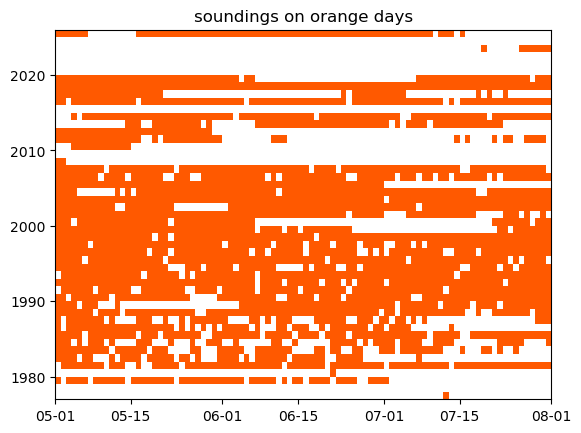

In [75]:
# plot Aminidivi sounding file availability after downloading as much as possible from UWyo.
dtup = Dates.yearmonthday.(dts) # Vector{Tuple{Int}[3]}

years = minimum(dtup)[1]:maximum(dtup)[1]+1
month_day_dt = Date(2000,5,1):Date(2000,8,1)
issond = falses(length(years)-1, length(month_day_dt)-1)
for (y, m, d) in dtup
    if 5 <= m <= 7
        yi = y - minimum(dtup)[1] + 1
        di = (Date(2000,m,d) - Date(2000,5,1)).value + 1
        # print("$y $m $d\n")
        issond[yi, di] = true
    end
end

mdates = matplotlib.dates
clf()
pcolormesh(month_day_dt, years, issond, vmin=0, vmax=2, cmap=ColorMap("hot_r")) # orange are soundings, white are gaps
ax = gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))  # e.g., 'Jul 01'
title("soundings on orange days")
gcf()

In [77]:
"Read and fill temperature, spechum, u_wind, v_wind from Aminidivi files."
function read_data!( temperature, spechum, u_wind, v_wind; pavg = (t,p) -> itp(t, p).(plevs) )
    for (i, f) in enumerate(amini_files)     # loop over files and extract data
        dt = extract_datetime(f)
        println("Processing file: $f with datetime: $dt")
        ds = NCDatasets.Dataset(joinpath(amini_dir, f))
        
        # Extract variables
        pressure  = ds["pressure"][:]
        if sum(isfinite.(pressure)) > 3
            dewpoint  = ds["dewpoint"][:]

            temperature[:,i] .= pavg( ds["temperature"][:],  pressure) # C
            spechum[    :,i] .= pavg( qs.(1e2*pressure, dewpoint),  pressure)
            u_wind[     :,i] .= pavg( ds["u_wind"][:], pressure)

            # hack v wind if truncated from data set
            wind_direction = ds["direction"][:]
            wind_speed = ds["speed"][:]
            v_wind[     :,i] .= pavg( -cosd.(wind_direction) .* wind_speed, pressure )
        end
    end
end


read_data!

In [78]:
# read sounding data from local disk

# allocate arrays for the variables
nit() = Matrix{Union{Float64, Missing}}(missing, length(plevs), length(amini_files))
temperature = nit()
spechum     = nit()
u_wind      = nit()
v_wind      = nit()

read_data!( temperature, spechum, u_wind, v_wind; pavg = (t,p) -> itp(t, p).(plevs) )
th = theta.(temperature.+273.15, plevs)

Processing file: aminidivi19770712_0000.nc with datetime: 1977-07-12T00:00:00
Processing file: aminidivi19790501_1200.nc with datetime: 1979-05-01T12:00:00
Processing file: aminidivi19790503_1200.nc with datetime: 1979-05-03T12:00:00
Processing file: aminidivi19790504_1200.nc with datetime: 1979-05-04T12:00:00
Processing file: aminidivi19790505_1200.nc with datetime: 1979-05-05T12:00:00
Processing file: aminidivi19790506_1200.nc with datetime: 1979-05-06T12:00:00
Processing file: aminidivi19790508_1200.nc with datetime: 1979-05-08T12:00:00
Processing file: aminidivi19790509_1200.nc with datetime: 1979-05-09T12:00:00
Processing file: aminidivi19790510_1200.nc with datetime: 1979-05-10T12:00:00
Processing file: aminidivi19790511_1200.nc with datetime: 1979-05-11T12:00:00
Processing file: aminidivi19790512_1200.nc with datetime: 1979-05-12T12:00:00
Processing file: aminidivi19790513_1200.nc with datetime: 1979-05-13T12:00:00
Processing file: aminidivi19790515_1200.nc with datetime: 1979-0

┌ Warning: Duplicated knots were deduplicated. Use Interpolations.deduplicate_knots!(knots) explicitly to avoid this warning.
│   k1 = Float32[6.1, 6.2, 6.3, 6.5, 7.4, 7.8, 8.1, 8.5, 8.8, 8.8, 9.2, 9.7, 10.0, 10.1, 10.6, 11.1, 11.6, 12.1, 12.6, 12.7, 13.3, 13.9, 14.6, 15.2, 15.9, 16.7, 17.5, 17.9, 18.3, 19.2, 20.0, 20.1, 21.0, 22.0, 23.1, 24.1, 25.3, 25.4, 26.5, 27.8, 29.1, 30.0, 30.5, 30.7, 32.0, 33.6, 35.2, 37.0, 37.5, 38.8, 40.8, 42.8, 45.0, 46.8, 47.3, 49.7, 50.0, 52.2, 53.7, 54.9, 57.8, 59.3, 60.8, 64.1, 67.5, 70.0, 71.2, 75.1, 79.2, 82.8, 83.6, 88.1, 93.0, 100.0, 104.0, 106.0, 111.0, 112.0, 123.0, 143.0, 149.0, 150.0, 154.0, 181.0, 200.0, 213.0, 237.0, 250.0, 253.0, 274.0, 281.0, 295.0, 300.0, 301.0, 325.0, 338.0, 345.0, 356.0, 375.0, 389.0, 400.0, 404.0, 414.0, 417.0, 432.0, 445.0, 449.0, 454.0, 457.0, 460.0, 465.0, 468.0, 476.0, 487.0, 490.0, 495.0, 500.0, 506.0, 515.0, 516.0, 520.0, 521.0, 538.0, 543.0, 547.0, 551.0, 564.0, 569.0, 582.0, 600.0, 663.0, 685.0, 696.0, 700.0, 701.

Processing file: aminidivi20140622_0000.nc with datetime: 2014-06-22T00:00:00
Processing file: aminidivi20140623_0000.nc with datetime: 2014-06-23T00:00:00
Processing file: aminidivi20140624_0000.nc with datetime: 2014-06-24T00:00:00
Processing file: aminidivi20140625_0000.nc with datetime: 2014-06-25T00:00:00
Processing file: aminidivi20140626_0000.nc with datetime: 2014-06-26T00:00:00
Processing file: aminidivi20140627_0000.nc with datetime: 2014-06-27T00:00:00
Processing file: aminidivi20140628_0000.nc with datetime: 2014-06-28T00:00:00
Processing file: aminidivi20140629_0000.nc with datetime: 2014-06-29T00:00:00
Processing file: aminidivi20140630_0000.nc with datetime: 2014-06-30T00:00:00


┌ Warning: Duplicated knots were deduplicated. Use Interpolations.deduplicate_knots!(knots) explicitly to avoid this warning.
│   k1 = Float32[6.2, 6.3, 6.5, 7.4, 7.8, 8.1, 8.5, 8.8, 8.8, 9.2, 9.7, 10.0, 10.1, 10.6, 11.1, 11.6, 12.1, 12.6, 12.7, 13.3, 13.9, 14.6, 15.2, 15.9, 16.7, 17.5, 17.9, 18.3, 19.2, 20.0, 20.1, 21.0, 22.0, 23.1, 24.1, 25.3, 25.4, 26.5, 27.8, 29.1, 30.0, 30.5, 30.7, 32.0, 33.6, 35.2, 37.0, 37.5, 38.8, 40.8, 42.8, 45.0, 46.8, 47.3, 49.7, 50.0, 52.2, 53.7, 54.9, 57.8, 59.3, 60.8, 64.1, 67.5, 70.0, 71.2, 75.1, 79.2, 82.8, 83.6, 88.1, 93.0, 100.0, 104.0, 106.0, 111.0, 112.0, 123.0, 143.0, 149.0, 150.0, 154.0, 181.0, 200.0, 213.0, 237.0, 250.0, 253.0, 274.0, 281.0, 295.0, 300.0, 301.0, 325.0, 338.0, 345.0, 356.0, 375.0, 389.0, 400.0, 404.0, 414.0, 417.0, 432.0, 445.0, 449.0, 454.0, 457.0, 460.0, 465.0, 468.0, 476.0, 487.0, 490.0, 495.0, 500.0, 506.0, 515.0, 516.0, 520.0, 521.0, 538.0, 543.0, 547.0, 551.0, 564.0, 569.0, 582.0, 600.0, 663.0, 685.0, 696.0, 700.0, 701.0, 71

Processing file: aminidivi20140701_0000.nc with datetime: 2014-07-01T00:00:00
Processing file: aminidivi20140702_0000.nc with datetime: 2014-07-02T00:00:00
Processing file: aminidivi20140703_0000.nc with datetime: 2014-07-03T00:00:00
Processing file: aminidivi20140706_0000.nc with datetime: 2014-07-06T00:00:00
Processing file: aminidivi20140707_0000.nc with datetime: 2014-07-07T00:00:00
Processing file: aminidivi20140708_0000.nc with datetime: 2014-07-08T00:00:00
Processing file: aminidivi20140709_0000.nc with datetime: 2014-07-09T00:00:00


...

┌ Warning: Duplicated knots were deduplicated. Use Interpolations.deduplicate_knots!(knots) explicitly to avoid this warning.
│   k1 = Float32[7.2, 7.5, 7.9, 8.1, 8.2, 8.6, 9.0, 9.4, 9.9, 10.0, 10.3, 10.8, 11.3, 11.8, 11.8, 12.3, 12.5, 12.9, 13.5, 14.2, 14.8, 15.5, 16.3, 17.0, 17.2, 17.8, 18.7, 19.6, 20.0, 20.5, 21.5, 22.6, 23.7, 24.8, 25.0, 26.0, 27.3, 28.7, 30.0, 30.1, 31.6, 33.2, 34.8, 36.3, 36.6, 38.5, 40.4, 42.4, 44.6, 46.9, 47.6, 49.2, 50.0, 51.7, 54.4, 55.2, 57.2, 60.2, 63.4, 66.6, 66.7, 70.0, 70.2, 74.1, 78.1, 82.4, 86.9, 90.9, 91.7, 100.0, 105.0, 118.0, 122.0, 125.0, 128.0, 129.0, 146.0, 147.0, 149.0, 150.0, 154.0, 200.0, 210.0, 220.0, 250.0, 270.0, 274.0, 286.0, 293.0, 300.0, 312.0, 348.0, 356.0, 358.0, 366.0, 374.0, 380.0, 388.0, 399.0, 400.0, 405.0, 419.0, 444.0, 448.0, 454.0, 460.0, 476.0, 500.0, 503.0, 565.0, 569.0, 584.0, 591.0, 600.0, 607.0, 616.0, 652.0, 690.0, 700.0, 755.0, 850.0, 866.0, 900.0, 913.0, 925.0, 991.0, 1000.0, 1007.0]
└ @ Interpolations /home/deszoeks/.ju

Processing file: aminidivi20140719_0000.nc with datetime: 2014-07-19T00:00:00
Processing file: aminidivi20140721_0000.nc with datetime: 2014-07-21T00:00:00
Processing file: aminidivi20140722_0000.nc with datetime: 2014-07-22T00:00:00
Processing file: aminidivi20140723_0000.nc with datetime: 2014-07-23T00:00:00
Processing file: aminidivi20140724_0000.nc with datetime: 2014-07-24T00:00:00
Processing file: aminidivi20140725_0000.nc with datetime: 2014-07-25T00:00:00
Processing file: aminidivi20140726_0000.nc with datetime: 2014-07-26T00:00:00
Processing file: aminidivi20140727_0000.nc with datetime: 2014-07-27T00:00:00
Processing file: aminidivi20140728_0000.nc with datetime: 2014-07-28T00:00:00
Processing file: aminidivi20140729_0000.nc with datetime: 2014-07-29T00:00:00
Processing file: aminidivi20140730_0000.nc with datetime: 2014-07-30T00:00:00
Processing file: aminidivi20140731_0000.nc with datetime: 2014-07-31T00:00:00
Processing file: aminidivi20160501_0000.nc with datetime: 2016-0

┌ Warning: Duplicated knots were deduplicated. Use Interpolations.deduplicate_knots!(knots) explicitly to avoid this warning.
│   k1 = Float32[45.1, 50.0, 55.9, 66.0, 70.0, 75.3, 77.8, 81.3, 84.6, 85.0, 92.4, 100.0, 105.0, 126.5, 127.0, 150.0, 157.0, 163.3, 190.0, 200.0, 207.6, 246.0, 247.0, 248.0, 250.0, 252.0, 257.0, 260.2, 262.0, 264.0, 265.0, 267.0, 268.0, 300.0, 322.7, 342.0, 359.0, 376.0, 385.0, 396.8, 400.0, 420.0, 438.0, 484.0, 484.0, 496.0, 500.0, 506.0, 522.9, 539.0, 564.4, 576.0, 586.2, 588.0, 608.7, 612.0, 622.0, 629.0, 631.9, 650.0, 655.8, 673.0, 693.0, 700.0, 705.9, 715.0, 732.0, 745.0, 757.0, 759.1, 786.8, 815.6, 850.0, 875.8, 907.2, 925.0, 939.4, 972.5, 984.0, 998.0, 1000.0, 1006.0, 1007.0]
└ @ Interpolations /home/deszoeks/.julia/packages/Interpolations/MbXSq/src/gridded/gridded.jl:81
┌ Warning: Duplicated knots were deduplicated. Use Interpolations.deduplicate_knots!(knots) explicitly to avoid this warning.
│   k1 = Float32[45.1, 50.0, 55.9, 66.0, 70.0, 75.3, 77.8, 81

Processing file: aminidivi20250708_0000.nc with datetime: 2025-07-08T00:00:00
Processing file: aminidivi20250709_0000.nc with datetime: 2025-07-09T00:00:00
Processing file: aminidivi20250711_0000.nc with datetime: 2025-07-11T00:00:00
Processing file: aminidivi20250712_0000.nc with datetime: 2025-07-12T00:00:00
Processing file: aminidivi20250713_0000.nc with datetime: 2025-07-13T00:00:00
Processing file: aminidivi20250715_0000.nc with datetime: 2025-07-15T00:00:00


21×3054 Matrix{Union{Missing, Float64}}:
 297.55   303.75   302.55   302.55   …  301.35   300.35   300.75   299.75
 300.136  302.003  301.351  301.635     301.638  301.166  301.743  301.083
 302.974  306.363  290.979  306.086     302.739  303.107  303.249  302.531
 306.1    311.548  308.405  307.985     304.633  305.471  305.471  304.633
 307.421  312.325  312.538  310.193     307.314  307.602  308.19   307.503
 309.041  313.385  313.582  312.284  …  310.945  310.127  311.322  310.712
 311.012  314.778  313.67   313.006     314.335  313.67   315.221  313.449
 313.143  317.499  325.66   314.953     316.709  316.688  316.968  316.39
 315.759  320.738  325.61   317.38      320.055  319.681  319.074  318.905
 318.965  324.604  326.033  320.39      325.061  323.242  323.399  323.105
   ⋮                                 ⋱    ⋮                        
 332.288  335.93   333.589  334.629     337.231  336.451  335.15   336.19
 334.322  337.16   335.943  336.484     341.181  340.179  339.356  33

In [129]:
# compute profile climatology for each date of the monsoon season
mddt = monthday.(dts)
cdt=sort(unique(mddt))
c_th = climprof(th,          mddt, cdt)
c_t  = climprof(temperature, mddt, cdt)
c_q  = climprof(spechum,     mddt, cdt)
c_u  = climprof(u_wind,      mddt, cdt)
c_v  = climprof(v_wind,      mddt, cdt)

21×324 Matrix{Float64}:
  -6.34415   -11.5911    -14.9429   …    2.67678    10.898     -2.45746
  -2.55009   -11.7424    -12.2176        5.05424    12.8423     5.36574
   2.51108    -0.737683   -4.13032       8.07147    15.5353     4.94415
   6.42788    -2.07055     4.33013       5.07142    15.5885     3.36465
   9.00016     4.62246     4.3236        5.29591     8.00845   -0.12941
   9.66036     5.3313      4.31708  …    5.51856     7.1763     1.67471
   7.66044     2.0         4.49951       7.66044     6.34415    0.0
  -0.933015   -1.15529    -2.82          4.77564     7.2259     1.78338
  -0.475503  -18.2266    -15.0193        1.6126      8.26475    4.8083
  -2.62509    -8.47047   -10.8368        1.18053     9.3036     1.3267
   ⋮                                ⋱                         
 -41.8402    -28.9778     -6.8944        2.29813    15.4548     6.06218
 -37.5609    -27.3189    -20.5015       -0.664626   12.1353    15.5639
 -32.909     -40.7839    -29.0019        1.21554     7.0

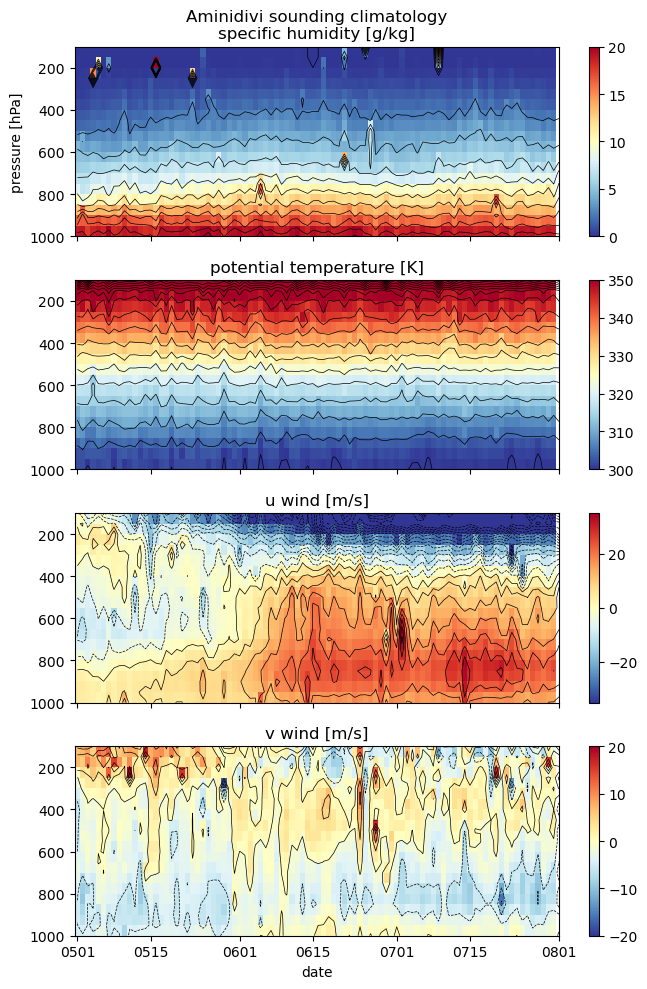

In [168]:
# plot climatology 

clf()
formatter = PyPlot.matplotlib.dates.DateFormatter("%m%d")
fig, axs = subplots(4,1, figsize=(7,10), sharex=true)
for ax in axs
    ax.invert_yaxis()
    ax.xaxis.set_major_formatter(formatter)
end

fit = findall(map(x-> (5,1) <= x <= (8,1), cdt))
dt = [ DateTime.(2000, d...) for d in cdt[fit] ]
pd = permutedims
trm(x) = x[1:end-1, fit[1:end-1]]

ax=axs[1]
pc = ax.pcolormesh(dt.-Hour(12), plevs, 1e3*trm(c_q), vmin=0, vmax=20, cmap=PyPlot.cm.RdYlBu_r, shading="auto")
colorbar(pc)
cr = ax.contour(dt, plevs, 1e3*c_q[:,fit], levels=0:2:24, colors="k", linewidths=0.5)
ax.set_ylabel("pressure [hPa]")
ax.set_title("Aminidivi sounding climatology\nspecific humidity [g/kg]")

ax=axs[2]
pc = ax.pcolormesh(dt.-Hour(12), plevs, trm(c_th), vmin=300, vmax=350, cmap=PyPlot.cm.RdYlBu_r, shading="auto")
colorbar(pc)
cr = ax.contour(dt, plevs, c_th[:,fit], levels=295:5:400, colors="k", linewidths=0.5)
ax.set_title("potential temperature [K]")

ax=axs[3]
pc = ax.pcolormesh(dt.-Hour(12), plevs, trm(c_u), vmin=-35, vmax=35, cmap=PyPlot.cm.RdYlBu_r, shading="auto")
colorbar(pc)
cr = ax.contour(dt, plevs, c_u[:,fit], levels=-60:5:60, colors="k", linewidths=0.5)
ax.set_title("u wind [m/s]")

ax=axs[4]
pc = ax.pcolormesh(dt.-Hour(12), plevs, trm(c_v), vmin=-20, vmax=20, cmap=PyPlot.cm.RdYlBu_r, shading="auto")
colorbar(pc)
cr = ax.contour(dt, plevs, c_v[:,fit], levels=-60:5:60, colors="k", linewidths=0.5)
ax.set_title("v wind [m/s]")
ax.set_xlabel("date")

for ax in axs
    ax.set_ylim(1000, 100)
end
tight_layout()
fmt = ["png", "pdf", "svg", "eps"]
[ savefig("amini_clim_sond.$f") for f in fmt ]

gcf()

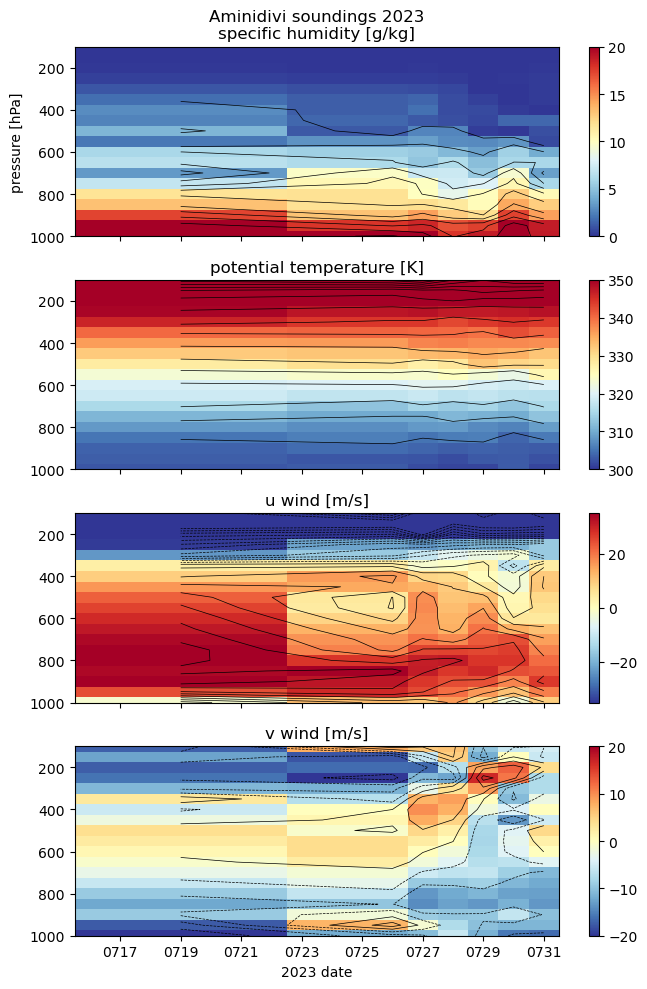

In [ ]:
# plot year
year = 2023

fit = findall( DateTime(year,5,1) .<= dts .<= DateTime(year,8,31) )

clf()
formatter = PyPlot.matplotlib.dates.DateFormatter("%m%d")
fig, axs = subplots(4,1, figsize=(7,10), sharex=true)
for ax in axs
    ax.invert_yaxis()
    ax.xaxis.set_major_formatter(formatter)
end

ax=axs[1]
pc = ax.pcolormesh(dts[fit], plevs, 1e3*spechum[:,fit], vmin=0, vmax=20, cmap=PyPlot.cm.RdYlBu_r, shading="auto")
colorbar(pc)
cr = ax.contour(dts[fit], plevs, 1e3*spechum[:,fit], levels=0:2:24, colors="k", linewidths=0.5)
ax.set_ylabel("pressure [hPa]")
ax.set_title("Aminidivi soundings $(year)\nspecific humidity [g/kg]")

ax=axs[2]
pc = ax.pcolormesh(dts[fit], plevs, th[:,fit], vmin=300, vmax=350, cmap=PyPlot.cm.RdYlBu_r, shading="auto")
colorbar(pc)
cr = ax.contour(dts[fit], plevs, th[:,fit], levels=295:5:400, colors="k", linewidths=0.5)
ax.set_title("potential temperature [K]")

ax=axs[3]
pc = ax.pcolormesh(dts[fit], plevs, u_wind[:,fit], vmin=-35, vmax=35, cmap=PyPlot.cm.RdYlBu_r, shading="auto")
colorbar(pc)
cr = ax.contour(dts[fit], plevs, u_wind[:,fit], levels=-60:5:60, colors="k", linewidths=0.5)
ax.set_title("u wind [m/s]")

ax=axs[4]
pc = ax.pcolormesh(dts[fit], plevs, v_wind[:,fit], vmin=-20, vmax=20, cmap=PyPlot.cm.RdYlBu_r, shading="auto")
colorbar(pc)
cr = ax.contour(dts[fit], plevs, v_wind[:,fit], levels=-60:5:60, colors="k", linewidths=0.5)
ax.set_title("v wind [m/s]")
ax.set_xlabel("$(year) date")

for ax in axs
    ax.set_ylim(1000, 100)
end
tight_layout()
fmt = ["png", "pdf", "svg", "eps"]
[ savefig("amini_sond_$(year).$f") for f in fmt ]

gcf()


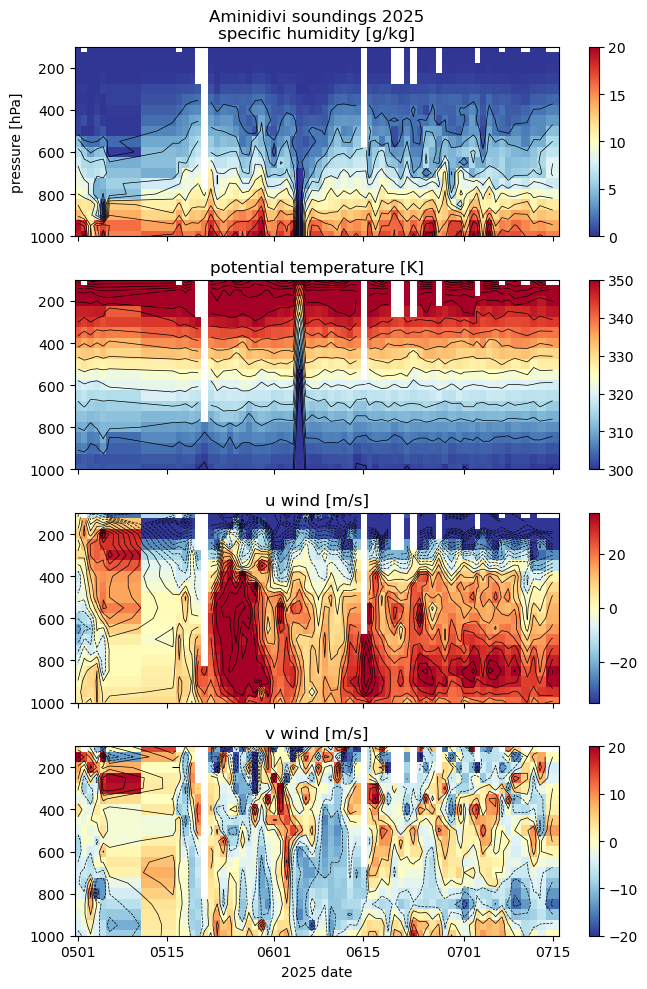

In [ ]:
# plot year
year = 2025

fit = findall( DateTime(year,5,1) .<= dts .<= DateTime(year,7,31) )

clf()
formatter = PyPlot.matplotlib.dates.DateFormatter("%m%d")
fig, axs = subplots(4,1, figsize=(7,10), sharex=true)
for ax in axs
    ax.invert_yaxis()
    ax.xaxis.set_major_formatter(formatter)
end

ax=axs[1]
pc = ax.pcolormesh(dts[fit], plevs, 1e3*spechum[:,fit], vmin=0, vmax=20, cmap=PyPlot.cm.RdYlBu_r, shading="auto")
colorbar(pc)
cr = ax.contour(dts[fit], plevs, 1e3*spechum[:,fit], levels=0:2:24, colors="k", linewidths=0.5)
ax.set_ylabel("pressure [hPa]")
ax.set_title("Aminidivi soundings $(year)\nspecific humidity [g/kg]")

ax=axs[2]
pc = ax.pcolormesh(dts[fit], plevs, th[:,fit], vmin=300, vmax=350, cmap=PyPlot.cm.RdYlBu_r, shading="auto")
colorbar(pc)
cr = ax.contour(dts[fit], plevs, th[:,fit], levels=295:5:400, colors="k", linewidths=0.5)
ax.set_title("potential temperature [K]")

ax=axs[3]
pc = ax.pcolormesh(dts[fit], plevs, u_wind[:,fit], vmin=-35, vmax=35, cmap=PyPlot.cm.RdYlBu_r, shading="auto")
colorbar(pc)
cr = ax.contour(dts[fit], plevs, u_wind[:,fit], levels=-60:5:60, colors="k", linewidths=0.5)
ax.set_title("u wind [m/s]")

ax=axs[4]
pc = ax.pcolormesh(dts[fit], plevs, v_wind[:,fit], vmin=-20, vmax=20, cmap=PyPlot.cm.RdYlBu_r, shading="auto")
colorbar(pc)
cr = ax.contour(dts[fit], plevs, v_wind[:,fit], levels=-60:5:60, colors="k", linewidths=0.5)
ax.set_title("v wind [m/s]")
ax.set_xlabel("$(year) date")

for ax in axs
    ax.set_ylim(1000, 100)
end
tight_layout()
fmt = ["png", "pdf", "svg", "eps"]
[ savefig("amini_sond_$(year).$f") for f in fmt ]

gcf()


In [ ]:
#=
# average same dates together across all years
function clim(dt, x, cdt, bintest = (x,y) -> ==(monthday(x), monthday(y)) )
    nt = length(cdt)
    ax = zeros(Float64, nt)
    sx = zeros(Int64,     nt)
    for j in 1:nt
        d = dt[j]
        y = x[j]
        ii = bintest.(d, cdt)
        # print("$(size(ii)), $(sum(ii))")
        if any(ii) && !ismissing(y) && isfinite(y)
            ax[ii] += y
            sx[ii] += 1
        end
    end
    return ax./sx
end

"vertical profile climatology x(height, time)"
function climprof(x, dts=dts, cdt=month_day_dt)
    c = zeros(axes(x,1), axes(cdt,1))
    for i in axes(x,1) # loop over vertical
        z = clim(dts, x[i,:], cdt)
        print(size(z))
        c[i,:] .= clim(dts, x[i,:], cdt)[:]
    end
    return c
end
=#

climprof